my code

In [1]:
import pandas as pd, matplotlib.pyplot as plt, numpy as np
import re

exo_data = pd.read_csv("exoplanet_archive_multiplanet_systems.csv", skiprows=299)
obliquity_data = pd.read_csv("obliquity_catalog.csv")

def clean_system_name(name):
    name = str(name).strip().replace("_", " ")
    name = re.sub(r"\s+", " ", name)
    name = re.sub(r"-(0+)(\d+)\b", lambda match: f"-{int(match.group(2))}", name)
    return name

def host_name(name):
    return re.sub(r"\s+[a-z]$", "", clean_system_name(name))

def has_planet_letter(name):
    return bool(re.search(r"\s+[a-z]$", clean_system_name(name)))

# Fill key planet and stellar properties across duplicate rows before choosing one preferred row.
exo_filled = exo_data.sort_values(["pl_name", "rowupdate"], ascending=[True, False]).copy()
for column in ["pl_orbsmax", "pl_rade", "pl_radj", "pl_bmasse", "pl_bmassj", "st_teff", "st_rad"]:
    exo_filled[column] = exo_filled.groupby("pl_name")[column].transform(lambda values: values.bfill().ffill())

# For duplicated planet entries, prefer the row that contains the projected obliquity.
exo_preferred = (
    exo_filled
    .assign(has_projobliq=exo_filled["pl_projobliq"].notna())
    .sort_values(["pl_name", "has_projobliq", "rowupdate"], ascending=[True, False, False])
    .drop_duplicates(subset="pl_name", keep="first")
    .reset_index(drop=True)
)
exo_preferred["pl_name_clean"] = exo_preferred["pl_name"].apply(clean_system_name)
exo_preferred["hostname_clean"] = exo_preferred["hostname"].apply(clean_system_name)
exo_preferred["Source"] = pd.NA

# Keep only projected-obliquity rows from the extra catalogue.
obliquity_extra = obliquity_data.loc[
    (obliquity_data["Pflag"] == "y")
    & obliquity_data["lambda"].notna()
    & (obliquity_data["lambda"] != -999)
].copy()
obliquity_extra["system_clean"] = obliquity_extra["System"].apply(clean_system_name)
obliquity_extra["host_clean"] = obliquity_extra["System"].apply(host_name)

# Fill missing projected obliquities only when that planet does not already have one in the archive.
added_count = 0
imported_count = 0
new_rows = []
for _, row in obliquity_extra.iterrows():
    system_clean = row["system_clean"]
    host_clean = row["host_clean"]
    planet_named = has_planet_letter(row["System"])

    if planet_named:
        if exo_preferred.loc[
            (exo_preferred["pl_name_clean"] == system_clean) & exo_preferred["pl_projobliq"].notna()
        ].shape[0] > 0:
            continue
    else:
        first_planet_rows = (
            exo_preferred.loc[exo_preferred["hostname_clean"] == host_clean]
            .sort_values(["pl_orbsmax", "pl_name"], ascending=[True, True])
        )
        if first_planet_rows.loc[first_planet_rows["pl_projobliq"].notna()].shape[0] > 0:
            continue

    target_rows = []
    if planet_named:
        target_rows = exo_preferred.index[exo_preferred["pl_name_clean"] == system_clean].tolist()
    if not target_rows:
        target_rows = (
            exo_preferred.loc[exo_preferred["hostname_clean"] == host_clean]
            .sort_values(["pl_orbsmax", "pl_name"], ascending=[True, True])
            .index
            .tolist()
        )

    if not target_rows:
        new_row = {column: pd.NA for column in exo_preferred.columns}
        new_row["hostname"] = host_clean
        new_row["pl_name"] = system_clean if planet_named else host_clean
        new_row["pl_projobliq"] = row["lambda"]
        new_row["st_teff"] = row["Teff"]
        new_row["pl_name_clean"] = clean_system_name(new_row["pl_name"])
        new_row["hostname_clean"] = host_clean
        new_row["Source"] = row["Ephemeris_reference"]
        new_row["has_projobliq"] = True
        new_rows.append(new_row)
        imported_count += 1
        continue

    target_index = target_rows[0]
    exo_preferred.loc[target_index, "pl_projobliq"] = row["lambda"]
    exo_preferred.loc[target_index, "Source"] = row["Ephemeris_reference"]
    added_count += 1

if new_rows:
    exo_preferred = pd.concat([exo_preferred, pd.DataFrame(new_rows)], ignore_index=True)

# Keep all planets in systems that now have at least one projected obliquity measurement.
hosts_with_projobliq = exo_preferred.loc[
    exo_preferred["pl_projobliq"].notna(),
    "hostname"
].unique()
systems_with_all_planets = (
    exo_preferred.loc[exo_preferred["hostname"].isin(hosts_with_projobliq)]
    .sort_values(["hostname", "pl_orbsmax", "pl_name"], ascending=[True, True, True])
    .reset_index(drop=True)
)

# Mark which planet provides the projected obliquity measurement.
systems_with_all_planets["has_projobliq"] = systems_with_all_planets["pl_projobliq"].notna()

# Log all projected-obliquity planets in each system, including systems with multiple such planets.
obliquity_planets_by_system = (
    systems_with_all_planets.loc[systems_with_all_planets["has_projobliq"]]
    .groupby("hostname")["pl_name"]
    .apply(lambda planets: ", ".join(planets))
)
systems_with_all_planets["obliquity_planets"] = systems_with_all_planets["hostname"].map(obliquity_planets_by_system)

print("Added projected obliquities from extra catalog:", added_count)
print("Imported systems missing from archive:", imported_count)
print("Number of systems:", systems_with_all_planets["hostname"].nunique())
print("Number of planets:", len(systems_with_all_planets))

systems_with_all_planets[[
    "hostname",
    "pl_name",
    "pl_projobliq",
    "has_projobliq",
    "obliquity_planets",
    "Source",
    "pl_orbsmax",
    "pl_rade",
    "pl_bmasse",
    "pl_radj",
    "pl_bmassj",
    "st_teff",
    "st_rad",
]].head(20)

systems_with_all_planets.to_csv("Matched_filtered.csv")

/var/folders/4v/jfc0xcx54rv11lmjnmw_dmvw0000gp/T/ipykernel_10807/2661456697.py:4: DtypeWarning: Columns (0: hd_name, 1: hip_name) have mixed types. Specify dtype option on import or set low_memory=False.
  exo_data = pd.read_csv("exoplanet_archive_multiplanet_systems.csv", skiprows=299)


Added projected obliquities from extra catalog: 6
Imported systems missing from archive: 4
Number of systems: 234
Number of planets: 313


Plotting code

In [2]:
"""
User supplied system values
"""
user_systems = [
    {
        "hostname": "KOI-6194",
        "pl_name": "KOI-6194 b",
        "sy_pnum": 2,
        "pl_orbsmax": 0.25,
        "pl_radj": 0.97,
        "pl_bmassj": 0.76,
        "st_rad": 5.63,
        "st_mass": 1.23,
        "st_teff": 4725.29 ,
        "pl_projobliq": np.nan,
        "st_inc": 90, # degrees
        "Source": "User supplied",
    },
    {
        "hostname": "KOI-6194",
        "pl_name": "KOI-6194 c",
        "sy_pnum": 2,
        "pl_orbsmax": 0.33,
        "pl_radj": np.nan,
        "pl_bmassj": 0.81,
        "st_rad": 5.63,
        "st_mass": 1.23,
        "st_teff": 4725.29,
        "pl_projobliq": np.nan,
        "st_inc": 90, # degrees
        "Source": "User supplied",
    },
    # https://exoplanetarchive.ipac.caltech.edu/overview/Kepler-56
    { # unless otherwise, sourced from https://ui.adsabs.harvard.edu/abs/2024ApJS..270....8W/abstract
        "hostname": "Kepler-56",
        "pl_name": "Kepler-56 b",
        "sy_pnum": 3,
        "pl_orbsmax": 0.1113862791,
        "pl_radj": 0.4254,
        "pl_bmassj": 0.11453698380, #Msin(i)
        "st_rad": 4.21799, #https://ui.adsabs.harvard.edu/abs/2019AJ....158..138S/abstract
        "st_mass": 1.6720,
        "st_teff": 4819.44, #https://ui.adsabs.harvard.edu/abs/2019AJ....158..138S/abstract
        "pl_projobliq": np.nan,
        "st_inc": 43, # degrees, https://ui.adsabs.harvard.edu/abs/2013Sci...342..331H/abstract
        "Source": "User supplied",
    },
    { # unless otherwise, sourced from https://ui.adsabs.harvard.edu/abs/2024ApJS..270....8W/abstract
        "hostname": "Kepler-56",
        "pl_name": "Kepler-56 c",
        "sy_pnum": 3,
        "pl_orbsmax": 0.1790751782,
        "pl_radj": 0.97154,
        "pl_bmassj": 0.7412321949, #Msin(i)
        "st_rad": 4.21799, #https://ui.adsabs.harvard.edu/abs/2019AJ....158..138S/abstract
        "st_mass": 1.6720,
        "st_teff": 4819.44, #https://ui.adsabs.harvard.edu/abs/2019AJ....158..138S/abstract
        "pl_projobliq": np.nan,
        "st_inc": 43, # degrees, https://ui.adsabs.harvard.edu/abs/2013Sci...342..331H/abstract
        "Source": "User supplied",
    },
    { # unless otherwise, sourced from https://ui.adsabs.harvard.edu/abs/2024ApJS..270....8W/abstract
        "hostname": "Kepler-56",
        "pl_name": "Kepler-56 d",
        "sy_pnum": 3,
        "pl_orbsmax": 2.314216894,
        "pl_radj": np.nan,
        "pl_bmassj": 6.4335081770, #Msin(i)
        "st_rad": 4.21799, #https://ui.adsabs.harvard.edu/abs/2019AJ....158..138S/abstract
        "st_mass": 1.6720,
        "st_teff": 4819.44, #https://ui.adsabs.harvard.edu/abs/2019AJ....158..138S/abstract
        "pl_projobliq": np.nan,
        "st_inc": 43, # degrees, https://ui.adsabs.harvard.edu/abs/2013Sci...342..331H/abstract
        "Source": "User supplied",
    },
    { # unless otherwise, sourced from https://ui.adsabs.harvard.edu/abs/2015ApJ...803...49Q/abstract
        "hostname": "Kepler-432",
        "pl_name": "Kepler-432 b",
        "sy_pnum": 2,
        "pl_orbsmax": 0.301, # AU
        "pl_radj": 1.367, # Rj
        "pl_bmassj": 5.41, # Mj
        "st_rad": 4.06, # Rsolar
        "st_mass": 1.32 , # Msolar
        "st_teff": 4995, # Tsolar
        "pl_projobliq": np.nan,
        "st_inc": 90, # degrees
        "Source": "User supplied",
    },
    { # unless otherwise, sourced from https://ui.adsabs.harvard.edu/abs/2015ApJ...803...49Q/abstract
        "hostname": "Kepler-432",
        "pl_name": "Kepler-432 c",
        "sy_pnum": 2,
        "pl_orbsmax": 1.188, # asin(i), AU
        "pl_radj": np.nan, # Rj
        "pl_bmassj": 2.63, # Msin(i), Mj
        "st_rad": 4.06, # Rsolar
        "st_mass": 1.32 , # Msolar
        "st_teff": 4995, # Tsolar
        "pl_projobliq": np.nan,
        "st_inc": 90, # degrees
        "Source": "User supplied",
    },
]

In [3]:
for r in user_systems["st_inc"]:
    print(r)

TypeError: list indices must be integers or slices, not str

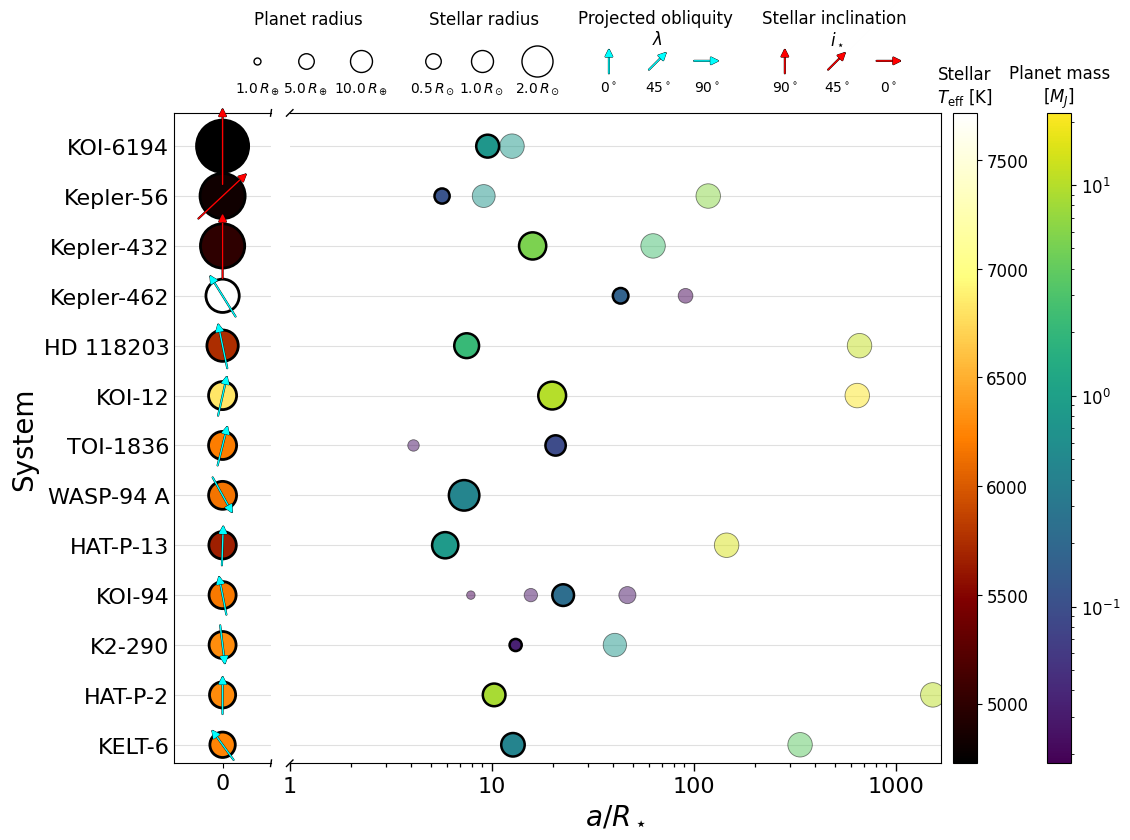

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patheffects as pe
from matplotlib.colors import Normalize, LogNorm
from matplotlib.cm import ScalarMappable
import re

RSUN_IN_AU = 0.00465047
RJUP_PER_REARTH = 11.209
MEARTH_PER_MJUP = 317.828

def load_matched_filtered_csv(path):
    data = pd.read_csv(path, comment="#")
    unnamed_columns = [column for column in data.columns if str(column).startswith("Unnamed") or column == ""]
    if unnamed_columns:
        data = data.rename(columns={unnamed_columns[0]: "match_row"})
    return data

def drop_duplicate_columns(df):
    duplicated = df.columns[df.columns.duplicated()].tolist()
    if duplicated:
        print(f"Dropping duplicate columns: {duplicated}")
    return df.loc[:, ~df.columns.duplicated()].copy()

# Normalise names so hostnames and planet names can be compared reliably.
def clean_name(name):
    name = str(name).strip().replace("_", " ")
    name = re.sub(r"\s+", " ", name)
    name = re.sub(r"-(0+)(\d+)\b", lambda match: f"-{int(match.group(2))}", name)
    return name

# Remove a trailing planet letter so system-level names map to a host consistently.
def extract_host_name(name):
    return re.sub(r"\s+[a-z]$", "", clean_name(name))

# Keep the final planet letter so the measured-obliquity planet can be highlighted.
def extract_planet_letter(name):
    match = re.search(r"\s+([a-z])$", clean_name(name))
    return match.group(1) if match else np.nan

def add_obliquity_glyph(
    ax,
    x,
    y,
    psi_deg,
    length_points,
    lw=1.0,
    color="cyan",
    outline_color="black",
    outline_lw=1.5,
    transform=None,
    stellar_inc = False
):
    base_transform = ax.transData if transform is None else transform
    # if transform is None:
    #     psi = np.deg2rad(psi_deg - 90.0)
    # else:
    if not stellar_inc:
        psi = np.deg2rad(90.0 - psi_deg)
    else:
        psi = np.deg2rad(psi_deg)
    center_x_px, center_y_px = base_transform.transform((x, y))
    half_length_px = 0.5 * length_points * ax.figure.dpi / 72.0
    dx_px = half_length_px * np.cos(psi)
    dy_px = half_length_px * np.sin(psi)
    x1, y1 = base_transform.inverted().transform((center_x_px - dx_px, center_y_px - dy_px))
    x2, y2 = base_transform.inverted().transform((center_x_px + dx_px, center_y_px + dy_px))
    annotation = ax.annotate(
        "",
        xy=(x2, y2),
        xytext=(x1, y1),
        xycoords=base_transform,
        textcoords=base_transform,
        annotation_clip=False,
        zorder=8,
        arrowprops=dict(
            arrowstyle="-|>",
            color=color,
            lw=lw,
            shrinkA=0,
            shrinkB=0,
            mutation_scale=12,
        ),
    )
    annotation.arrow_patch.set_path_effects([
        pe.Stroke(linewidth=outline_lw, foreground=outline_color),
        pe.Normal(),
    ])
    return annotation

def marker_diameter_points(marker_area_points2):
    return 2.0 * np.sqrt(marker_area_points2 / np.pi)

def select_plot_obliquity_rows(
    matched_df,
    system_col="host_clean",
    system_label_col="hostname",
    planet_name_col="pl_name",
    obliquity_col="pl_projobliq",
    obliquity_planet_col="planet_letter",
    archive_planet_letter_col="planet_letter_archive",
    sort_col="stellar_radius_plot",
):
    data = drop_duplicate_columns(matched_df.copy())
    data[obliquity_col] = pd.to_numeric(data[obliquity_col], errors="coerce").where(lambda series: series != -999)
    data[archive_planet_letter_col] = data[archive_planet_letter_col].fillna(data[planet_name_col].apply(extract_planet_letter))
    data[obliquity_planet_col] = data[obliquity_planet_col].fillna(data[archive_planet_letter_col])
    selected = (
        data.assign(has_projected_obliquity=data[obliquity_col].notna())
        .sort_values([system_col, "has_projected_obliquity", sort_col], ascending=[True, False, False])
        .drop_duplicates(subset=[system_col], keep="first")
        .sort_values(sort_col, ascending=False)
        .reset_index(drop=True)
    )
    return selected

def build_matched_systems(matched_filtered_path, user_systems=None):
    matched_filtered_raw = drop_duplicate_columns(load_matched_filtered_csv(matched_filtered_path))
    user_systems = [] if user_systems is None else user_systems
    user_systems_raw = drop_duplicate_columns(pd.DataFrame(user_systems))
    if not user_systems_raw.empty and "Source" not in user_systems_raw.columns:
        user_systems_raw = user_systems_raw.assign(Source="User supplied")
    user_systems_raw = drop_duplicate_columns(user_systems_raw)

    all_columns = list(dict.fromkeys(list(matched_filtered_raw.columns) + list(user_systems_raw.columns)))
    combined_raw = pd.concat(
        [
            matched_filtered_raw.reindex(columns=all_columns),
            user_systems_raw.reindex(columns=all_columns),
        ],
        ignore_index=True,
    )
    combined_raw = drop_duplicate_columns(combined_raw)
    combined = combined_raw.copy()
    combined = combined.replace(r"^\s*$", np.nan, regex=True)

    numeric_columns = [
        "sy_pnum",
        "pl_orbsmax",
        "pl_orbper",
        "pl_rade",
        "pl_radj",
        "pl_bmasse",
        "pl_bmassj",
        "pl_projobliq",
        "st_teff",
        "st_rad",
        "st_mass",
    ]
    present_numeric_columns = [column for column in numeric_columns if column in combined_raw.columns]
    for column in present_numeric_columns:
        combined[column] = pd.to_numeric(combined[column], errors="coerce")

    semi_major_axis = combined["pl_orbsmax"].copy()
    if {"pl_orbper", "st_mass"}.issubset(combined.columns):
        stellar_mass = combined["st_mass"].where(combined["st_mass"] > 0, 1.0).fillna(1.0)
        missing_semi_major_axis = semi_major_axis.isna() | (semi_major_axis <= 0)
        valid_period = combined["pl_orbper"] > 0
        kepler_mask = missing_semi_major_axis & valid_period
        semi_major_axis.loc[kepler_mask] = (
            stellar_mass.loc[kepler_mask] * (combined.loc[kepler_mask, "pl_orbper"] / 365.25) ** 2
        ) ** (1.0 / 3.0)
    semi_major_axis = semi_major_axis.where(semi_major_axis > 0)

    planet_radius_rj = combined["pl_radj"].copy() if "pl_radj" in combined.columns else pd.Series(np.nan, index=combined.index)
    if "pl_rade" in combined.columns:
        planet_radius_rj = planet_radius_rj.fillna(combined["pl_rade"] / RJUP_PER_REARTH)
    radius_measured = planet_radius_rj.notna()
    default_planet_radius_rj = planet_radius_rj.dropna().median() if planet_radius_rj.notna().any() else 0.3
    planet_radius_rj = planet_radius_rj.fillna(default_planet_radius_rj)
    planet_radius_re = combined["pl_rade"].copy() if "pl_rade" in combined.columns else pd.Series(np.nan, index=combined.index)
    planet_radius_re = planet_radius_re.fillna(planet_radius_rj * RJUP_PER_REARTH)

    planet_mass_mj = combined["pl_bmassj"].copy() if "pl_bmassj" in combined.columns else pd.Series(np.nan, index=combined.index)
    if "pl_bmasse" in combined.columns:
        planet_mass_mj = planet_mass_mj.fillna(combined["pl_bmasse"] / MEARTH_PER_MJUP)
    planet_mass_mj = planet_mass_mj.where(planet_mass_mj > 0)

    stellar_radius = combined["st_rad"].copy() if "st_rad" in combined.columns else pd.Series(np.nan, index=combined.index)
    stellar_radius = stellar_radius.where(stellar_radius > 0)
    default_stellar_radius = stellar_radius.dropna().median() if stellar_radius.notna().any() else 1.0
    stellar_radius = stellar_radius.fillna(default_stellar_radius)
    stellar_radius_au = stellar_radius * RSUN_IN_AU

    stellar_teff = combined["st_teff"].copy() if "st_teff" in combined.columns else pd.Series(np.nan, index=combined.index)
    stellar_teff = stellar_teff.where(stellar_teff > 0)
    if "Teff" in combined.columns:
        teff_fallback = pd.to_numeric(combined["Teff"], errors="coerce")
        stellar_teff = stellar_teff.fillna(teff_fallback.where(teff_fallback > 0))
    default_stellar_teff = stellar_teff.dropna().median() if stellar_teff.notna().any() else 5500.0
    stellar_teff = stellar_teff.fillna(default_stellar_teff)

    derived_column_names = [
        "host_clean",
        "planet_letter_archive",
        "planet_letter",
        "semi_major_axis_plot",
        "planet_radius_rj",
        "planet_radius_re",
        "planet_mass_mj",
        "stellar_radius_plot",
        "stellar_radius_au",
        "stellar_teff_plot",
        "radius_measured",
        "a_over_rstar",
    ]
    combined = combined.drop(columns=derived_column_names, errors="ignore")
    combined = combined.assign(
        host_clean=combined["hostname"].map(clean_name),
        planet_letter_archive=combined["pl_name"].map(extract_planet_letter),
        planet_letter=combined["pl_name"].map(extract_planet_letter),
        semi_major_axis_plot=semi_major_axis,
        planet_radius_rj=planet_radius_rj,
        planet_radius_re=planet_radius_re,
        planet_mass_mj=planet_mass_mj,
        stellar_radius_plot=stellar_radius,
        stellar_radius_au=stellar_radius_au,
        stellar_teff_plot=stellar_teff,
        radius_measured=radius_measured,
        a_over_rstar=semi_major_axis / stellar_radius_au,
    )
    combined["a_over_rstar"] = combined["a_over_rstar"].where(combined["a_over_rstar"] > 0)
    combined["sy_pnum"] = combined["sy_pnum"].fillna(1)
    return drop_duplicate_columns(combined)

def plot_obliquity_system_architecture(
    matched_df,
    system_col="host_clean",
    system_label_col="hostname",
    planet_name_col="pl_name",
    x_col="a_over_rstar",
    planet_radius_col="planet_radius_re",
    planet_mass_col="planet_mass_mj",
    stellar_teff_col="stellar_teff_plot",
    stellar_radius_col="stellar_radius_plot",
    obliquity_col="pl_projobliq",
    obliquity_planet_col="planet_letter",
    archive_planet_letter_col="planet_letter_archive",
    radius_measured_col="radius_measured",
    sort_col=None,
    host_x=0.0,
    star_size_scale=250.0,
    planet_size_scale=25.0,
    tick_size = 16,
    title_size = 20,
    subtitle_size = 12
    ):

    input_duplicate_cols = matched_df.columns[matched_df.columns.duplicated()].tolist()
    if input_duplicate_cols:
        print(f"Dropping duplicate columns before plotting: {input_duplicate_cols}")
    data = drop_duplicate_columns(matched_df.copy())
    duplicate_cols = data.columns[data.columns.duplicated()].tolist()
    if duplicate_cols:
        raise ValueError(f"Input dataframe contains duplicate columns: {duplicate_cols}")
    data = data.dropna(subset=[system_col, system_label_col, planet_name_col, x_col]).copy()
    data = data.loc[data[x_col] > 0].copy()
    data[obliquity_col] = pd.to_numeric(data[obliquity_col], errors="coerce").where(lambda series: series != -999)
    data[archive_planet_letter_col] = data[archive_planet_letter_col].fillna(data[planet_name_col].apply(extract_planet_letter))
    data[obliquity_planet_col] = data[obliquity_planet_col].fillna(data[archive_planet_letter_col])

    if sort_col is None:
        sort_col = stellar_radius_col
    if data.columns.tolist().count(sort_col) != 1:
        raise ValueError(f"Sort column '{sort_col}' must exist exactly once. Found {data.columns.tolist().count(sort_col)} matches.")

    selected_system_rows = select_plot_obliquity_rows(
        data,
        system_col=system_col,
        system_label_col=system_label_col,
        planet_name_col=planet_name_col,
        obliquity_col=obliquity_col,
        obliquity_planet_col=obliquity_planet_col,
        archive_planet_letter_col=archive_planet_letter_col,
        sort_col=sort_col,
    )
    system_cols = [system_col, system_label_col, stellar_teff_col, stellar_radius_col, obliquity_col, obliquity_planet_col]
    systems = (
        selected_system_rows[system_cols]
        .reset_index(drop=True)
        .rename(
            columns={
                system_col: "system_key",
                system_label_col: "system_label",
                stellar_teff_col: "teff",
                stellar_radius_col: "stellar_radius",
                obliquity_col: "projected_obliquity",
                obliquity_planet_col: "obliquity_planet",
            }
        )
    )
    user_systems_df = pd.DataFrame(user_systems) if isinstance(user_systems, list) else pd.DataFrame()
    if not user_systems_df.empty and {"hostname", "st_inc"}.issubset(user_systems_df.columns):
        user_stellar_inclinations = (
            user_systems_df.loc[user_systems_df["st_inc"].notna(), ["hostname", "st_inc"]]
            .assign(system_key=lambda frame: frame["hostname"].map(clean_name))
            .drop_duplicates(subset=["system_key"], keep="first")
        )
        stellar_inclination_map = dict(zip(user_stellar_inclinations["system_key"], user_stellar_inclinations["st_inc"]))
    else:
        stellar_inclination_map = {}
    systems["stellar_inclination"] = systems["system_key"].map(stellar_inclination_map)
    systems["y"] = 1.35 * np.arange(len(systems))

    planets = (
        data[[system_col, system_label_col, planet_name_col, x_col, planet_radius_col, planet_mass_col, archive_planet_letter_col, radius_measured_col]]
        .drop_duplicates(subset=[system_col, planet_name_col], keep="first")
        .rename(
            columns={
                system_col: "system_key",
                system_label_col: "system_label",
                planet_name_col: "planet_name",
                x_col: "a_over_rstar",
                planet_radius_col: "planet_radius",
                planet_mass_col: "planet_mass",
                archive_planet_letter_col: "planet_letter",
                radius_measured_col: "radius_measured",
            }
        )
    )
    planets = planets.loc[planets["system_key"].isin(systems["system_key"])].copy()
    y_map = dict(zip(systems["system_key"], systems["y"]))
    planets["y"] = planets["system_key"].map(y_map)

    measured_planets = (
        planets.merge(
            systems[["system_key", "obliquity_planet"]],
            left_on=["system_key", "planet_letter"],
            right_on=["system_key", "obliquity_planet"],
            how="inner",
        )
        .drop(columns=["obliquity_planet"])
        .drop_duplicates(subset=["system_key", "planet_name"], keep="first")
    )

    stellar_sizes = star_size_scale * systems["stellar_radius"]
    stellar_marker_areas = stellar_sizes.copy()
    planet_sizes = planet_size_scale * planets["planet_radius"]
    measured_planet_sizes = planet_size_scale * measured_planets["planet_radius"]

    stellar_cmap = plt.cm.afmhot
    planet_cmap = plt.cm.viridis
    stellar_norm = Normalize(vmin=systems["teff"].min(), vmax=systems["teff"].max())
    valid_planet_masses = planets["planet_mass"].dropna()
    if valid_planet_masses.empty:
        valid_planet_masses = pd.Series([1.0])
    planet_norm = LogNorm(vmin=valid_planet_masses.min(), vmax=valid_planet_masses.max())

    positive_x = planets["a_over_rstar"].dropna()
    positive_x = positive_x.loc[positive_x > 0]
    x_min = 10 ** np.floor(np.log10(positive_x.min()))
    x_max = positive_x.max() * 1.1

    fig_height = max(5.8, 0.52 * len(systems) + 2.4)
    fig = plt.figure(figsize=(11.8, fig_height))
    gs = fig.add_gridspec(1, 2, width_ratios=[1.1, 7.4], wspace=0.05)
    host_ax = fig.add_subplot(gs[0, 0])
    planet_ax = fig.add_subplot(gs[0, 1], sharey=host_ax)
    fig.subplots_adjust(left=0.17, right=0.82, top=0.82)

    host_ax.set_xlim(-0.6, 0.6)
    host_ax.set_xticks([host_x])
    host_ax.set_xticklabels(["0"])
    host_ax.set_ylim(systems["y"].max() + 0.5, -0.9)
    host_ax.tick_params(axis="x", which="major", labelsize = tick_size)

    planet_ax.set_xscale("log")
    planet_ax.set_xlim(x_min, x_max)
    planet_ax.set_ylim(systems["y"].max() + 0.5, -0.9)
    planet_ax.xaxis.set_major_locator(mticker.LogLocator(base=10))
    planet_ax.xaxis.set_minor_locator(mticker.LogLocator(base=10, subs=np.arange(2, 10) * 0.1))
    planet_ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda value, _: f"{value:g}"))
    planet_ax.tick_params(axis="x", which="major", length=6, width=1.0, labelsize = tick_size)
    planet_ax.tick_params(axis="x", which="minor", length=3, width=0.9, labelsize = tick_size)

    for axis in (host_ax, planet_ax):
        for y in systems["y"]:
            axis.axhline(y, color="0.88", lw=0.8, zorder=0)

    host_ax.scatter(
        np.full(len(systems), host_x),
        systems["y"],
        s=stellar_sizes,
        c=systems["teff"],
        cmap=stellar_cmap,
        norm=stellar_norm,
        edgecolor="black",
        linewidth=2.0,
        zorder=4,
    )

    planet_masses = planets["planet_mass"].fillna(valid_planet_masses.min())
    measured_planet_masses = measured_planets["planet_mass"].fillna(valid_planet_masses.min())

    planet_ax.scatter(
        planets["a_over_rstar"],
        planets["y"],
        s=planet_sizes,
        c=planet_masses,
        cmap=planet_cmap,
        norm=planet_norm,
        edgecolor="black",
        linewidth=0.6,
        alpha=0.5,
        zorder=3,
    )
    planet_ax.scatter(
        measured_planets["a_over_rstar"],
        measured_planets["y"],
        s=measured_planet_sizes,
        c=measured_planet_masses,
        cmap=planet_cmap,
        norm=planet_norm,
        edgecolor="black",
        linewidth=1.8,
        alpha=1.0,
        zorder=5,
    )

    for y, projected_obliquity, marker_area in zip(systems["y"], systems["projected_obliquity"], stellar_marker_areas):
        if pd.notna(projected_obliquity):
            add_obliquity_glyph(
                ax=host_ax,
                x=host_x,
                y=y,
                psi_deg=projected_obliquity,
                length_points=1.3 * marker_diameter_points(marker_area),
                lw=1.0,
                color="cyan",
                outline_color="black",
                outline_lw=1.5,
            )

    for y, st_inc, marker_area in zip(systems["y"], systems["stellar_inclination"], stellar_marker_areas):
        if pd.notna(st_inc):
            add_obliquity_glyph(
                ax=host_ax,
                x=host_x,
                y=y,
                psi_deg=st_inc,
                length_points=1.3 * marker_diameter_points(marker_area),
                lw=1.0,
                color="red",
                outline_color="black",
                outline_lw=1.5,
                stellar_inc=True
            )

    host_ax.set_yticks(systems["y"])
    host_ax.set_yticklabels(systems["system_label"])
    planet_ax.tick_params(axis="y", left=False, labelleft=False, labelsize = tick_size)
    host_ax.invert_yaxis()
    planet_ax.invert_yaxis()

    host_ax.set_ylabel("System", fontsize=title_size)
    planet_ax.set_xlabel(r"$a/R_\star$", fontsize=title_size)

    host_ax.spines["right"].set_visible(False)
    planet_ax.spines["left"].set_visible(False)
    host_ax.tick_params(axis="y", length=0, labelsize = tick_size)
    planet_ax.tick_params(axis="y", length=0, labelsize = tick_size)

    d = 0.005
    kwargs = dict(transform=host_ax.transAxes, color="k", clip_on=False, lw=1.0)
    host_ax.plot((1 - d, 1 + d), (-d, +d), **kwargs)
    host_ax.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)
    kwargs.update(transform=planet_ax.transAxes)
    planet_ax.plot((-d, +d), (1 - d, 1 + d), **kwargs)
    planet_ax.plot((-d, +d), (-d, +d), **kwargs)

    stellar_sm = ScalarMappable(norm=stellar_norm, cmap=stellar_cmap)
    stellar_sm.set_array([])
    planet_sm = ScalarMappable(norm=planet_norm, cmap=planet_cmap)
    planet_sm.set_array([])
    cax1 = fig.add_axes([0.83, 0.11, 0.02, 0.71])
    cbar1 = fig.colorbar(stellar_sm, cax=cax1)
    cbar1.ax.set_title("Stellar\n$T_{\\rm eff}$ [K]", fontsize=subtitle_size, pad=8)
    cbar1.ax.tick_params(labelsize=tick_size-4)
    cax2 = fig.add_axes([0.91, 0.11, 0.02, 0.71])
    cbar2 = fig.colorbar(planet_sm, cax=cax2)
    cbar2.ax.set_title("Planet mass\n[$M_J$]", fontsize=subtitle_size, pad=8)
    cbar2.ax.tick_params(labelsize=tick_size-4)

    planet_radius_legend_vals = [1.0, 5.0, 10.0]
    stellar_radius_legend_vals = [0.5, 1.0, 2.0]

    legend_symbol_y = 1.08
    legend_label_y = 1.05
    legend_title_y = 1.13
    planet_xs = [-0.05, 0.025, 0.11]
    stellar_xs = [0.22, 0.295, 0.38]
    obliq_xs = [0.49, 0.565, 0.64]
    st_inc_xs = [0.76, 0.84, 0.92]

    planet_ax.text(np.mean(planet_xs), legend_title_y, "Planet radius", ha="center", va="bottom", fontsize=subtitle_size, transform=planet_ax.transAxes, clip_on=False)
    for x_pos, radius in zip(planet_xs, planet_radius_legend_vals):
        planet_ax.scatter(x_pos, legend_symbol_y, s=planet_size_scale * radius, facecolor="white", edgecolor="black", transform=planet_ax.transAxes, clip_on=False, zorder=7)
        planet_ax.text(x_pos, legend_label_y, rf"${radius:.1f}\,R_\oplus$", ha="center", va="top", fontsize=subtitle_size - 2, transform=planet_ax.transAxes, clip_on=False)

    planet_ax.text(np.mean(stellar_xs), legend_title_y, "Stellar radius", ha="center", va="bottom", fontsize=subtitle_size, transform=planet_ax.transAxes, clip_on=False)
    for x_pos, radius in zip(stellar_xs, stellar_radius_legend_vals):
        planet_ax.scatter(x_pos, legend_symbol_y, s=star_size_scale * radius, facecolor="white", edgecolor="black", transform=planet_ax.transAxes, clip_on=False, zorder=7)
        planet_ax.text(x_pos, legend_label_y, rf"${radius:.1f}\,R_\odot$", ha="center", va="top", fontsize=subtitle_size - 2, transform=planet_ax.transAxes, clip_on=False)

    planet_ax.text(obliq_xs[1], legend_title_y-0.03, "Projected obliquity \n$\\lambda$", ha="center", va="bottom", fontsize=subtitle_size, transform=planet_ax.transAxes, clip_on=False)
    for x_pos, projected_obliquity in zip(obliq_xs, [0, 45, 90]):
        add_obliquity_glyph(
            ax=planet_ax,
            x=x_pos,
            y=legend_symbol_y,
            psi_deg=projected_obliquity,
            length_points=18,
            lw=1.0,
            color="cyan",
            outline_color="black",
            outline_lw=1.5,
            transform=planet_ax.transAxes,
        )
        planet_ax.text(x_pos, legend_label_y, rf"${projected_obliquity}^\circ$", ha="center", va="top", fontsize=subtitle_size - 2, transform=planet_ax.transAxes, clip_on=False)

    planet_ax.text(st_inc_xs[1], legend_title_y-0.03, "Stellar inclination \n$i_\\star$", ha="center", va="bottom", fontsize=subtitle_size, transform=planet_ax.transAxes, clip_on=False)
    for x_pos, stellar_inclination in zip(st_inc_xs, [90 , 45, 0]):
        add_obliquity_glyph(
            ax=planet_ax,
            x=x_pos,
            y=legend_symbol_y,
            psi_deg=stellar_inclination,
            length_points=18,
            lw=1.0,
            color="red",
            outline_color="black",
            outline_lw=1.5,
            transform=planet_ax.transAxes,
            stellar_inc=True
        )
        planet_ax.text(x_pos, legend_label_y, rf"${stellar_inclination}^\circ$", ha="center", va="top", fontsize=subtitle_size - 2, transform=planet_ax.transAxes, clip_on=False)

    return fig, host_ax, planet_ax, systems, planets, measured_planets

try:
    user_systems
except NameError:
    user_systems = []

matched_systems_df = drop_duplicate_columns(build_matched_systems("Matched_filtered.csv", user_systems=user_systems))
matched_systems_df = drop_duplicate_columns(matched_systems_df)
plot_obliquity_rows = select_plot_obliquity_rows(matched_systems_df)
plot_obliquity_rows.loc[plot_obliquity_rows["pl_projobliq"].notna(), ["hostname", "pl_name", "planet_letter", "pl_projobliq", "Source"]].to_csv("obliquities_for_plot.csv", index=False)
matched_systems_df.to_csv("matched_systems.csv", index=False)

matched_systems_plot_df = drop_duplicate_columns(matched_systems_df.loc[matched_systems_df["sy_pnum"] > 1].copy())

top = 10

# Clean user hostnames from the user_systems input list
user_hostnames = {
    clean_name(system["hostname"])
    for system in user_systems
    if "hostname" in system and pd.notna(system["hostname"])
}

# Use the full dataframe here, not the sy_pnum > 1 filtered one
user_system_keys = set(
    matched_systems_df.loc[
        matched_systems_df["host_clean"].isin(user_hostnames)
        | matched_systems_df["Source"].eq("User supplied"),
        "host_clean",
    ]
    .dropna()
    .unique()
)

# Only use sy_pnum > 1 for choosing the largest archive comparison systems
largest_pool = matched_systems_df.loc[
    (matched_systems_df["sy_pnum"] > 1)
    & (~matched_systems_df["host_clean"].isin(user_system_keys))
].copy()

largest_systems = (
    largest_pool
    .sort_values("stellar_radius_plot", ascending=False)
    .drop_duplicates(subset=["host_clean"], keep="first")
    .head(top)["host_clean"]
)

systems_to_keep = set(largest_systems).union(user_system_keys)

# Now filter the full dataframe, so user systems are retained even if sy_pnum <= 1
matched_systems_plot_df = matched_systems_df.loc[
    matched_systems_df["host_clean"].isin(systems_to_keep)
].copy()

matched_systems_plot_df = drop_duplicate_columns(matched_systems_plot_df)

fig, host_ax, planet_ax, systems, planets, measured_planets = plot_obliquity_system_architecture(
    matched_systems_plot_df,
    system_col="host_clean",
    system_label_col="hostname",
    planet_name_col="pl_name",
    x_col="a_over_rstar",
    planet_radius_col="planet_radius_re",
    planet_mass_col="planet_mass_mj",
    stellar_teff_col="stellar_teff_plot",
    stellar_radius_col="stellar_radius_plot",
    obliquity_col="pl_projobliq",
    obliquity_planet_col="planet_letter",
    archive_planet_letter_col="planet_letter_archive",
    radius_measured_col="radius_measured",
)
plt.show()
fig.savefig('/Users/jvel0761/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/Documents/TASC10 2026/alignment_plots.png', dpi=400)

In [ ]:
matched_systems_plot_df

,match_row,rowid,pl_name,hostname,pl_letter,hd_name,hip_name,tic_id,gaia_dr2_id,gaia_dr3_id,...,planet_letter,semi_major_axis_plot,planet_radius_rj,planet_radius_re,planet_mass_mj,stellar_radius_plot,stellar_radius_au,stellar_teff_plot,radius_measured,a_over_rstar
28,28.0,1081.0,HAT-P-13 b,HAT-P-13,b,NaN,NaN,TIC 20096620,Gaia DR2 1014520826353577088,Gaia DR3 1014520826353577088,...,b,0.042700,1.272000,14.258000,0.851000,1.56000,0.007255,5653.0,True,5.885813
29,29.0,1086.0,HAT-P-13 c,HAT-P-13,c,NaN,NaN,TIC 20096620,Gaia DR2 1014520826353577088,Gaia DR3 1014520826353577088,...,c,1.188000,1.113500,12.481222,14.280000,1.75600,0.008166,5653.0,False,145.477250
36,36.0,1165.0,HAT-P-2 b,HAT-P-2,b,HD 147506,HIP 80076,TIC 39903405,Gaia DR2 1380825667768742144,Gaia DR3 1380825667768742144,...,b,0.067700,0.951000,10.659759,8.620000,1.41600,0.006585,6290.0,True,10.280839
37,37.0,1175.0,HAT-P-2 c,HAT-P-2,c,HD 147506,HIP 80076,TIC 39903405,Gaia DR2 1380825667768742144,Gaia DR3 1380825667768742144,...,c,8.964024,1.113500,12.481222,10.700000,1.24185,0.005775,5899.0,False,1552.161924
71,71.0,2212.0,HD 118203 b,HD 118203,b,HD 118203,HIP 66192,TIC 286923464,Gaia DR2 1560420854826284928,Gaia DR3 1560420854826284928,...,b,0.071300,1.140000,12.778238,2.140000,2.04000,0.009487,5742.0,True,7.515580
72,72.0,2217.0,HD 118203 c,HD 118203,c,HD 118203,HIP 66192,TIC 286923464,Gaia DR2 1560420854826284928,Gaia DR3 1560420854826284928,...,c,6.280000,1.113500,12.481222,11.790000,2.04000,0.009487,5742.0,False,661.961344
107,107.0,5445.0,K2-290 b,K2-290,b,NaN,NaN,TIC 70803960,Gaia DR2 6253844468882760832,Gaia DR3 6253844468883543680,...,b,0.092300,0.272995,3.060000,0.034295,1.51100,0.007027,6302.0,True,13.135312
108,108.0,5449.0,K2-290 c,K2-290,c,NaN,NaN,TIC 70803960,Gaia DR2 6253844468882760832,Gaia DR3 6253844468883543680,...,c,0.286000,1.010000,11.320000,0.774000,1.51100,0.007027,6302.0,True,40.700966
122,122.0,6359.0,KELT-6 b,KELT-6,b,NaN,NaN,TIC 165987272,Gaia DR2 1464700950221781504,Gaia DR3 1464700950221781504,...,b,0.079390,1.020000,11.433160,0.440000,1.34000,0.006232,6246.0,True,12.739845
123,123.0,6360.0,KELT-6 c,KELT-6,c,NaN,NaN,TIC 165987272,Gaia DR2 1464700950221781504,Gaia DR3 1464700950221781504,...,c,2.390000,1.113500,12.481222,3.710000,1.52900,0.007111,6272.0,False,336.119391


In [ ]:
print(0.33/(5.63*RSUN_IN_AU))

12.604008805832766


Minimum mutual inclination

In [ ]:
import numpy as np

def min_mutual_inclination_from_non_transit(
    a_nontransit,
    r_star,
    i_transit=90.0,
    degrees=True,
):
    """
    Estimate the minimum mutual inclination needed for one planet to transit
    while another planet at a_nontransit does not transit.

    Parameters
    ----------
    a_nontransit : float
        Semi-major axis of the non-transiting planet.
        Must be in same units as r_star.
    r_star : float
        Stellar radius, same units as a_nontransit.
    i_transit : float
        Inclination of the transiting planet in degrees.
        Use ~90 deg if unknown.
    degrees : bool
        If True, return result in degrees.

    Returns
    -------
    delta_i_min : float
        Minimum mutual inclination.
    transit_half_angle : float
        Transit-zone half-angle of the non-transiting planet.
    """

    ratio = r_star / a_nontransit

    if ratio >= 1:
        raise ValueError("The star radius is larger than or equal to the semi-major axis.")

    theta_tr = np.arcsin(ratio) #degrees

    i_offset_transit = np.abs(np.deg2rad(90.0 - i_transit)) #radians

    delta_i_min = np.maximum(0.0, theta_tr - i_offset_transit)

    if degrees:
        return np.rad2deg(delta_i_min), np.rad2deg(theta_tr)

    return delta_i_min, theta_tr

delta_i_min, theta_tr = min_mutual_inclination_from_non_transit(
    a_nontransit=0.33,   # AU
    r_star=5.63*0.00465,     # R_sun in AU approximately
    i_transit=90,
)

print(delta_i_min, theta_tr)

4.550159667863981 4.550159667863981
